In [ ]:
# @title 1. Mount Google Drive and Set Up File Paths
from google.colab import drive
import os
from pathlib import Path

# Mount your Google Drive
print("Mounting Google Drive...")
drive.mount('/content/drive')
print("Google Drive mounted.")

Mounting Google Drive...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Google Drive mounted.


In [ ]:
# @title 2. File Paths Set Up

OTHER_PREFIX = ""

# @markdown if u have prefix want to add other the given denoise_prefix, check the bool and the type sth in the OTHER_PREFIX
OTHER_PREFIX_bool = True # @param{type: "boolean"}

if OTHER_PREFIX_bool == True:
    OTHER_PREFIX = "float" # @param{type: "string"}
    OTHER_PREFIX =  OTHER_PREFIX + "_"
# @markdown ---

EMPIAR_ID = 10017 # @param{type : 'string'}

DATA_DIR_PATH = '/content/drive/MyDrive/cryo_project/Test_on_10017/Test_0_9-8_9-30_EM_10017/data'     # @param {type: "string"}
DATA_DIR_PATH = DATA_DIR_PATH + f'/EMPIAR-{EMPIAR_ID}/micrographs'
DATA_DIR = Path(DATA_DIR_PATH)

OUTPUT_DIR_PATH ='/content/drive/MyDrive/cryo_project/Test_on_10017/Test_0_9-8_9-30_EM_10017/data'  # @param {type: "string"}
OUTPUT_DIR_PATH = OUTPUT_DIR_PATH + f'/EMPIAR-{EMPIAR_ID}/C-CSN-D_{OTHER_PREFIX}micrographs'
OUTPUT_DIR = Path(OUTPUT_DIR_PATH)

TEMP_DIR_PATH = '/content/temp_denoise'                           # @param {type: "string"}
TEMP_DIR = Path(TEMP_DIR_PATH)


!mkdir {OUTPUT_DIR_PATH} -p
!mkdir {TEMP_DIR_PATH} -p


print(f"\nOriginal Data Directory: {DATA_DIR}")
print(f"Output Directory: {OUTPUT_DIR}")
print(f"Temporary Directory: {TEMP_DIR}")

# Create output and temporary directories if they don't exist
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
TEMP_DIR.mkdir(parents=True, exist_ok=True)


Original Data Directory: /content/drive/MyDrive/cryo_project/Test_on_10017/Test_0_9-8_9-30_EM_10017/data/EMPIAR-10017/micrographs
Output Directory: /content/drive/MyDrive/cryo_project/Test_on_10017/Test_0_9-8_9-30_EM_10017/data/EMPIAR-10017/C-CSN-D_float_micrographs
Temporary Directory: /content/temp_denoise


In [ ]:
# @title 3-0. install mrcfile package
!pip install mrcfile -qq

In [ ]:
# @title 3. Import Packages
import subprocess
import shutil
import time
from dataclasses import dataclass, field
import sys

import numpy as np
import mrcfile
import cv2
# from numpy.fft import fft2, ifft2

from scipy.fftpack import fft2, ifft2
from scipy.signal.windows import gaussian
from skimage.exposure import equalize_adapthist
from skimage.restoration import denoise_nl_means

In [ ]:
# @title 4. Load in Denoise Process Functions Copy From CryoSegNet

# Code for implementing different different image processing techniques for denoising.

def transform(image):
    i_min = image.min()
    i_max = image.max()

    image = (image - i_min)/(i_max - i_min)
    return image

def standard_scaler(image):
    # Ensure all initial processing uses float32
    image = image.astype(np.float32)
    kernel_size = 9
    image = cv2.GaussianBlur(image, (kernel_size, kernel_size), 0)
    mu = np.mean(image)
    sigma = np.std(image)
    image = (image - mu) / sigma
    # Normalize to a 0-1 range, which is standard for float images
    transform(image)
    return image.astype(np.float32)

def contrast_enhancement(image):
    # we may have to adjust the hyperparameter
    denoised_image = denoise_nl_means(image, h=0.1, fast_mode=True, patch_size=5, patch_distance=6)
    return denoised_image


def gaussian_kernel(kernel_size = 3):
    h = gaussian(kernel_size, kernel_size / 3).reshape(kernel_size, 1)
    h = np.dot(h, h.transpose())
    h /= np.sum(h)
    return h.astype(np.float32)

def wiener_filter(img, kernel, K):
    # This function works with floating-point data, so no changes are needed
    kernel /= np.sum(kernel)
    dummy = np.copy(img)
    dummy = fft2(dummy)
    kernel = fft2(kernel, shape = img.shape)
    kernel = np.conj(kernel) / (np.abs(kernel) ** 2 + K)
    dummy = dummy * kernel
    dummy = np.abs(ifft2(dummy))
    return dummy.astype(np.float32)

def clahe(image):
    img_equalized = equalize_adapthist(image, clip_limit=0.03)
    return img_equalized.astype(np.float32)

def guided_filter(input_image, guidance_image, radius=20, epsilon=0.1):
    # Input images are already float32, so we remove the original conversions

    mean_guidance = cv2.boxFilter(guidance_image, -1, (radius, radius))
    mean_input = cv2.boxFilter(input_image, -1, (radius, radius))

    mean_guidance_input = cv2.boxFilter(guidance_image * input_image, -1, (radius, radius))
    covariance_guidance_input = mean_guidance_input - mean_guidance * mean_input

    mean_guidance_sq = cv2.boxFilter(guidance_image * guidance_image, -1, (radius, radius))
    variance_guidance = mean_guidance_sq - mean_guidance * mean_guidance

    a = covariance_guidance_input / (variance_guidance + epsilon)
    b = mean_input - a * mean_guidance
    mean_a = cv2.boxFilter(a, -1, (radius, radius))
    mean_b = cv2.boxFilter(b, -1, (radius, radius))

    output_image = mean_a * guidance_image + mean_b

    # Return the raw, non-scalarized float32 array
    return output_image.astype(np.float32)

def de_scale(image, original_min, original_max):
    """
    Scales a processed image back to its original intensity range.
    """
    i_min = image.min()
    i_max = image.max()

    # Scale the processed data to a 0-1 range
    scaled_image = (image - i_min) / (i_max - i_min)

    # Map the 0-1 range to the original data's range
    final_image = scaled_image * (original_max - original_min) + original_min

    return final_image.astype(np.float32)

Gaussian_kernel_size = 9
kernel = gaussian_kernel(Gaussian_kernel_size)

def denoise(image_path):
    # Read the image and store the original min and max values
    image = mrcfile.read(image_path)
    original_min = image.min()
    original_max = image.max()

    normalized_image = standard_scaler(np.array(image))

    contrast_enhanced_image = contrast_enhancement(normalized_image)
    weiner_filtered_image = wiener_filter(contrast_enhanced_image, kernel, K = 30)
    clahe_image = clahe(weiner_filtered_image)
    guided_filter_image = guided_filter(clahe_image, weiner_filtered_image)

    # Use the stored min and max to scale the final output
    final_denoised_image = de_scale(guided_filter_image, original_min, original_max)

    return final_denoised_image

In [ ]:
# @title 5. Denoise the mrcfile
"""
paths = DATA_DIR.rglob('*.mrc')
paths = sorted(list(paths))
n = 0
for path in paths:
    n += 1
    denoised_img = denoise(path)
    mrcfile.write(OUTPUT_DIR / path.name, denoised_img, overwrite=True)
    print(f"{n}. Denoised image saved to {OUTPUT_DIR / path.name}")
"""

'\npaths = DATA_DIR.rglob(\'*.mrc\')\npaths = sorted(list(paths))\nn = 0\nfor path in paths:\n    n += 1\n    denoised_img = denoise(path)\n    mrcfile.write(OUTPUT_DIR / path.name, denoised_img, overwrite=True)\n    print(f"{n}. Denoised image saved to {OUTPUT_DIR / path.name}")\n'

In [ ]:
# @title 5. Denoise the mrcfile CPU parallel ver.for denoise

from multiprocessing import Pool, cpu_count
from tqdm import tqdm
import os

# Assume all your functions (denoise, etc.) are defined above this section.

def process(image_path):
    """
    A helper function to process and save a single image.
    Returns the path of the saved file or an error message.
    """
    denoised_img = denoise(image_path)
    output_path = OUTPUT_DIR / image_path.name
    mrcfile.write(output_path, denoised_img, overwrite=True)
    return None


paths = sorted(list(DATA_DIR.rglob('*.mrc')))

num_processes = cpu_count()
print(f"Starting parallel denoising on {len(paths)} images with {num_processes} cores.")

with Pool(num_processes) as pool:
    results_iterator = pool.imap_unordered(process, paths)
    for result in tqdm(results_iterator, total=len(paths), desc="Denoising Progress"):
        pass

print("\nAll denoising tasks completed.")

Starting parallel denoising on 84 images with 8 cores.


Denoising Progress: 100%|██████████| 84/84 [04:49<00:00,  3.45s/it]



All denoising tasks completed.


---
### Result visualization

In [ ]:
# @title load in function for image reading
import os

# You may need to install mrcfile with: !pip install mrcfile

def load_mrc(path: str, standardize: bool = False):
    with mrcfile.open(path) as f:
        image = f.data
        header = f.header
        extended_header = f.extended_header

    if image.dtype == np.float16:
        image = image.astype(np.float32)

    if standardize:
        # Standardize based on header info if available, otherwise on mean/std
        if hasattr(header, 'amean') and hasattr(header, 'rms'):
            image = image - header.amean
            image /= header.rms
        else:
            image = (image - image.mean()) / image.std()

    return image, header, extended_header


def load_image(path: str, standardize: bool = False, make_image: bool = True):
    ext = os.path.splitext(path)[1]

    if ext == '.mrc':
        data = load_mrc(path, standardize)
    else:
        # Placeholder for other file types, though they are removed for brevity.
        raise ValueError("Unsupported file type.")

    (image, header, extended_header) = data if isinstance(data, tuple) else (data, None, None)

    return (image, header, extended_header) if header else image


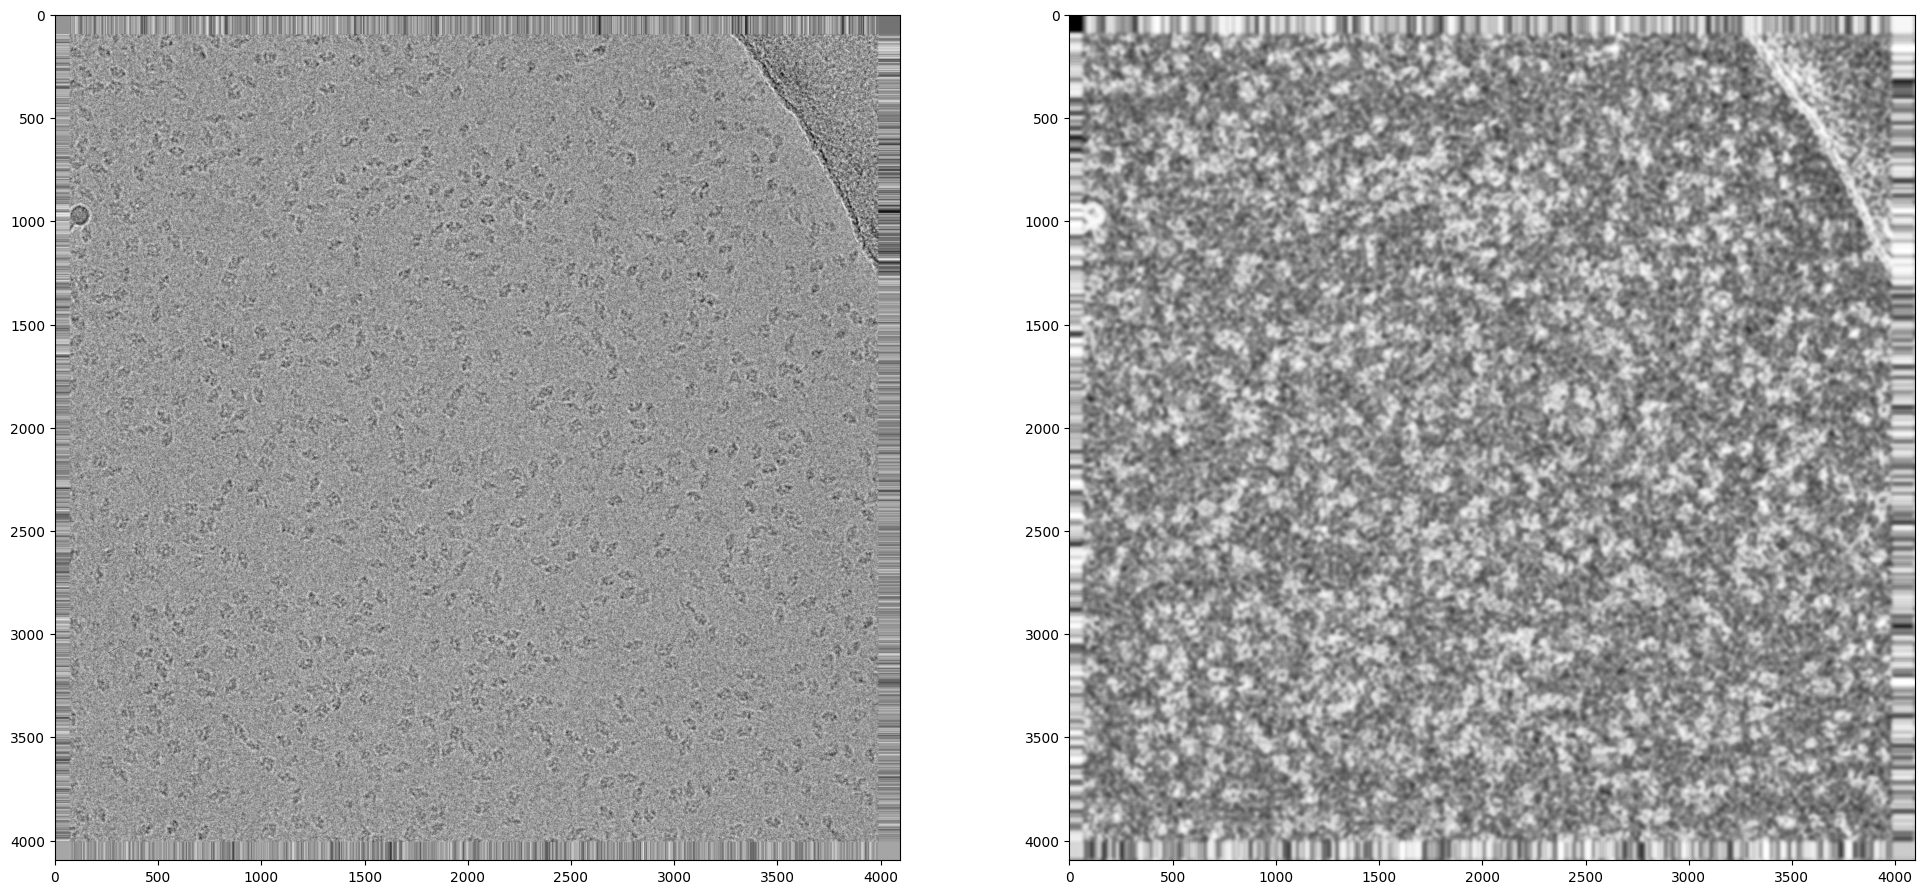

In [ ]:
import matplotlib.pyplot as plt

name = 'Falcon_2012_06_12-14_33_35_0' # @param {type: "string"}

# Load the raw micrograph, ensuring it's a NumPy array.
mic_raw = load_image(os.path.join(DATA_DIR_PATH, f"{name}.mrc"), standardize=True)[0]


# Load the denoised micrograph, ensuring it's a NumPy array.
mic_dn = load_image(os.path.join(OUTPUT_DIR_PATH, f"{name}.mrc"), standardize=True)[0]


# Plotting the images
_, ax = plt.subplots(1, 2, figsize=(24, 12))

ax[0].imshow(mic_raw, vmin=-4, vmax=4, cmap='Greys_r')
ax[1].imshow(mic_dn, vmin=-4, vmax=4, cmap='Greys_r')

plt.show()